In [14]:
import mne
import scipy
import numpy as np
import pandas as pd
import sys
sys.path.append("C:/Users/wg984/Wolfgang/repos/Bedmaster-ICU-tools/code/")
sys.path.append("/home/wolfgang/repos/Bedmaster-ICU-tools/code/")
from research_bm_tools import BMR_load, BMR_plot, get_metadata
import datetime
import h5py
import os
import traceback
# %matplotlib widget
import matplotlib.pyplot as plt
import time
import psutil
sys.path.append('/home/wolfgang/repos/sleep_research_io')
from sleep_research_functions import *

In [15]:
dir_input = f'/media/mad3/Projects/ICU_SLEEP_STUDY/Sleep_And_Breathing/sleeplab_files_step4'
files = os.listdir(dir_input)

In [25]:
write_to_hdf5?

Object `write_to_hdf5` not found.


In [16]:
signals = get_metadata(os.path.join(dir_input, files[0]))

In [17]:
signals

(['abd',
  'acc_ai_10sec',
  'acc_ai_1sec',
  'acc_enmo',
  'acc_enmo_10sec',
  'acc_enmo_1sec',
  'accx',
  'accx_1sec',
  'accy',
  'accy_1sec',
  'accz',
  'accz_1sec',
  'annotation',
  'apnea',
  'band',
  'band_unscaled',
  'cflow',
  'chest',
  'cpc_cntr_window',
  'cpc_hfc',
  'cpc_hfc_lfc_ratio',
  'cpc_lfc',
  'crcstatus',
  'deriv1',
  'ecg_signal',
  'epoch',
  'exht',
  'hrv_ac',
  'hrv_apen',
  'hrv_avgsqi',
  'hrv_btsdet',
  'hrv_dc',
  'hrv_fdflag',
  'hrv_hf',
  'hrv_iqr',
  'hrv_lf',
  'hrv_lfhf',
  'hrv_nn',
  'hrv_nnkurt',
  'hrv_nnmean',
  'hrv_nnmedian',
  'hrv_nnmode',
  'hrv_nnskew',
  'hrv_nnvariance',
  'hrv_pnn50',
  'hrv_rmssd',
  'hrv_rpeak',
  'hrv_sampen',
  'hrv_sd1',
  'hrv_sd1sd2',
  'hrv_sd2',
  'hrv_sdnn',
  'hrv_t_end',
  'hrv_t_start',
  'hrv_tdflag',
  'hrv_ttlpwr',
  'hrv_ulf',
  'hrv_vlf',
  'hrv_window_center',
  'hypo_10_60',
  'ibi',
  'ibi_cvar_1min',
  'ibi_cvar_2min',
  'ibi_cvar_30sec',
  'ibi_cvar_5min',
  'ibi_mean_5min',
  'ibi_std_5mi

In [18]:
data, hdr, fs = read_in_routine(os.path.join(dir_input, files[0]))

In [23]:
data.hrv_nn[data.hrv_rpeak==1]

2019-03-01 21:25:04.900    0.730
2019-03-01 21:25:05.600    0.740
2019-03-01 21:25:06.400    0.755
2019-03-01 21:25:07.200    0.775
2019-03-01 21:25:07.900    0.760
                           ...  
2019-03-02 05:44:45.800    0.745
2019-03-02 05:44:46.500    0.730
2019-03-02 05:44:47.200    0.730
2019-03-02 05:44:47.900    0.720
2019-03-02 05:44:48.700    0.715
Name: hrv_nn, Length: 35715, dtype: float32

In [24]:
data.hrv_nn

2019-03-01 21:25:04.200    0.73
2019-03-01 21:25:04.300    0.73
2019-03-01 21:25:04.400    0.73
2019-03-01 21:25:04.500    0.73
2019-03-01 21:25:04.600    0.73
                           ... 
2019-03-02 05:45:03.900     NaN
2019-03-02 05:45:04.000     NaN
2019-03-02 05:45:04.100     NaN
2019-03-02 05:45:04.200     NaN
2019-03-02 05:45:04.300     NaN
Freq: 100L, Name: hrv_nn, Length: 300002, dtype: float32

In [5]:
import pandas as pd
ss = pd.read_csv('summary_subjects.csv')
    

In [6]:
ss.study_id.unique().shape

(119,)

In [2]:
mad3drive = '/media/mad3/'
bmr_studyid_dir = os.path.join(mad3drive, 'Projects/ICU_SLEEP_STUDY/data/data_analysis/BMR_studyID/')
ecg_studyid_dir = os.path.join(mad3drive, 'Projects/ICU_SLEEP_STUDY/data/data_analysis/BMR_resampled_ECG/')

bm_files = os.listdir(bmr_studyid_dir)
bm_files.sort()
bm_file = bm_files[0]
print(bm_file)
bm_filepath = os.path.join(bmr_studyid_dir, bm_file)
lead = 'I'

lead_data = BMR_load(bm_filepath, signals = lead, loadEvents=0)


BMR_001.h5


In [43]:
signals_in_bm_file = get_metadata(bm_filepath)

In [46]:
BMR_load?

Signature:
BMR_load(
    filepath,
    signals=None,
    DateTimeSelectionTZ=None,
    hours_to_return=1,
    loadEvents=0,
)
Docstring: <no docstring>
File:      ~/repos/Bedmaster-ICU-tools/code/research_bm_tools.py
Type:      function


In [3]:
lead_data = lead_data[lead]
lead_data = lead_data

In [4]:
lead_data.set_index('datetime', inplace=True)
lead_data = lead_data[['signal']].astype(np.float32)

In [21]:
lead_data

,signal
datetime,
2018-06-05 07:17:34.000000,2
2018-06-05 07:17:34.004167,4
2018-06-05 07:17:34.008333,7
2018-06-05 07:17:34.012500,7
2018-06-05 07:17:34.016667,3
...,...
2018-06-08 14:32:46.945833,0
2018-06-08 14:32:46.950000,4
2018-06-08 14:32:46.954167,5


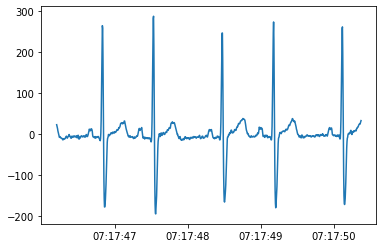

In [22]:
plt.plot(lead_data.iloc[3000:4000])

In [8]:
lead_data['signal'] = pd.to_numeric(lead_data['signal'], downcast='signed')

In [9]:
lead_data['signal']

datetime
2018-06-05 07:17:34.000000    2
2018-06-05 07:17:34.004167    4
2018-06-05 07:17:34.008333    7
2018-06-05 07:17:34.012500    7
2018-06-05 07:17:34.016667    3
                             ..
2018-06-08 14:32:46.945833    0
2018-06-08 14:32:46.950000    4
2018-06-08 14:32:46.954167    5
2018-06-08 14:32:46.958333    9
2018-06-08 14:32:46.962500    5
Name: signal, Length: 65106876, dtype: int16

In [40]:
lead_data2 = lead_data.iloc[10000 : 10000 + 240*3600].copy()

In [42]:
new_fs = 240
lead_data_original_start = lead_data2.index[0]
a = time.time()
lead_data2 = lead_data2.resample(datetime.timedelta(seconds = 1/new_fs)).mean()
print(time.time() - a)
a = time.time()
parts = np.max([lead_data2.shape[0]//(new_fs*3600*6), 1])
parts = 1
part_len = lead_data2.shape[0]//parts

for ipart in range(parts-1):
    lead_data2.iloc[ipart*part_len : (ipart+1)*part_len] = lead_data2.iloc[ipart*part_len : (ipart+1)*part_len].interpolate(method='pchip', order =3)
    
print(time.time() - a)

0.04195904731750488
0.0003161430358886719


In [25]:
part_len

217182

In [47]:
lead_data.shape

(65106876, 1)

In [48]:
lead_data.iloc[10000:100000000000000000000]

,signal
datetime,
2018-06-05 07:18:15.666667,7
2018-06-05 07:18:15.670833,9
2018-06-05 07:18:15.675000,11
2018-06-05 07:18:15.679167,10
2018-06-05 07:18:15.683333,9
...,...
2018-06-08 14:32:46.945833,0
2018-06-08 14:32:46.950000,4
2018-06-08 14:32:46.954167,5


In [40]:
65106876/240/3600

75.35518055555556

In [41]:
75*22/60

27.5

In [14]:
parts

1

In [15]:
part_len

868730

In [17]:
lead_data3 = lead_data2.copy()

In [18]:
lead_data3

,signal
datetime,
2018-06-05 07:18:15.665985,7.0
2018-06-05 07:18:15.670152,9.0
2018-06-05 07:18:15.674319,11.0
2018-06-05 07:18:15.678486,10.0
2018-06-05 07:18:15.682653,9.0
...,...
2018-06-05 08:18:35.643060,0.0
2018-06-05 08:18:35.647227,-4.0
2018-06-05 08:18:35.651394,-8.0


In [27]:
np.sum(lead_data3 != lead_data2)

signal    5520
dtype: int64